In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [2]:
X = np.array([[5.1, 3.5], [4.9, 3.0], [5.8, 2.7], [6.0, 3.0], [6.7, 3.1], [4.5, 2.3], [6.1, 2.8], [5.2, 3.2], [5.5, 2.6], [5.0, 2.0], [8.0, 0.5], [7.5, 0.8], [8.1, -0.1], [2.5, 3.5], [1.0, 3.0], [4.5, -1.0], [3.0, -0.5], [5.1, -0.2], [6.0, -1.5], [3.5, -0.1], [4.0, 0.0], [6.1, 0.5], [5.4, -0.5], [5.3, 0.3], [5.8, 0.6]])

u1 = np.array([3.0, 3.0])
u2 = np.array([2.0, 2.0])
centroids = np.array([u1, u2])

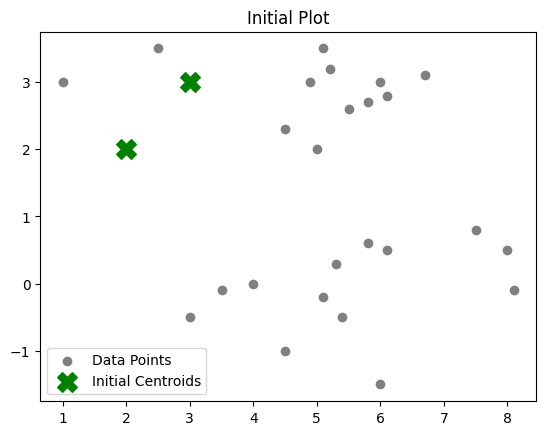

In [3]:
plt.scatter(X[:, 0], X[:, 1], c = 'gray', label = "Data Points")
plt.scatter(centroids[:, 0], centroids[:, 1], c = 'green', marker = 'X', s = 200, label = "Initial Centroids")
plt.title("Initial Plot")
plt.legend()
plt.show()

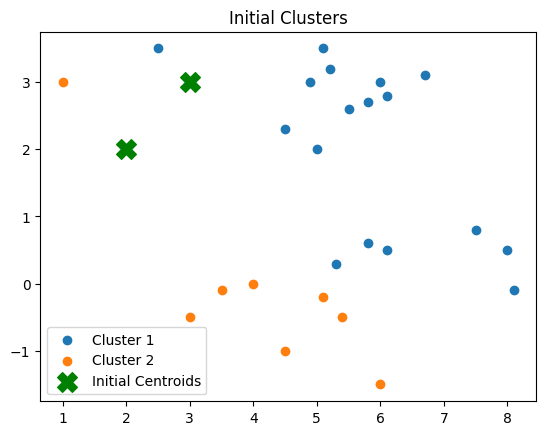


Starting iteration 1
Updated Centroids: [[ 5.77058824  2.01764706]
 [ 4.0625     -0.1       ]]

Starting iteration 2
Updated Centroids: [[ 5.8         2.125     ]
 [ 4.2        -0.05555556]]

Starting iteration 3
Updated Centroids: [[ 5.8         2.125     ]
 [ 4.2        -0.05555556]]

Convergence limit reached.


In [4]:
def initializeCentroids():
    return np.array([[3.0, 3.0], [2.0, 2.0]])

def euclideanDistance(firstPoint, secondPoint):
    sum = 0
    for i in range(2):
        difference = firstPoint[i] - secondPoint[i]
        sum += difference ** 2
    distance = sum ** 0.5
    return distance

def assignClusters(X, centroids):
    labels = []
    for point in X:
        minDistance = float('inf')
        closestCentroid = -1
        for i in range(len(centroids)):
            distance = euclideanDistance(point, centroids[i])
            if distance < minDistance:
                minDistance = distance
                closestCentroid = i
        labels.append(closestCentroid)
    return np.array(labels)

def updateCentroids(X, labels, k):
    newCentroids = []
    for i in range(k):
        clusterPoints = X[labels == i]
        if len(clusterPoints) > 0:
            sumX = 0
            sumY = 0
            for point in clusterPoints:
                sumX += point[0]
                sumY += point[1]
            sumX /= len(clusterPoints)
            sumY /= len(clusterPoints)
            newCentroids.append([sumX, sumY])
        else:
            newCentroids.append([0, 0])
    return np.array(newCentroids)

def hasConverged(oldCentroids, newCentroids, threshold):
    distance = 0
    for i in range(len(oldCentroids)):
        for j in range(len(oldCentroids[i])):
            distance += (oldCentroids[i][j] - newCentroids[i][j]) ** 2
    distance = distance ** 0.5
    return distance < threshold

def kMeans(X, k, maxIterations, threshold):
    centroids = initializeCentroids()
    for iteration in range(maxIterations):
        labels = assignClusters(X, centroids)

        if iteration == 0:
            for i in range(k):
                clusterPoints = X[labels == i]
                plt.scatter(clusterPoints[:, 0], clusterPoints[:, 1], label = "Cluster " + str(i + 1))
            plt.scatter(centroids[:, 0], centroids[:, 1], c = 'green', marker = 'X', s = 200, label = "Initial Centroids")
            plt.title("Initial Clusters")
            plt.legend()
            plt.show()

        print()
        print("Starting iteration " + str(iteration + 1))
        newCentroids = updateCentroids(X, labels, k)
        print("Updated Centroids: " + str(newCentroids))

        if hasConverged(centroids, newCentroids, threshold):
            print()
            print("Convergence limit reached.")
            break

        centroids = newCentroids

    if iteration == maxIterations - 1:
        print()
        print("Maximum iterations reached.")

    return centroids, labels

finalCentroids, labels = kMeans(X, 2, 100, 1e-4)

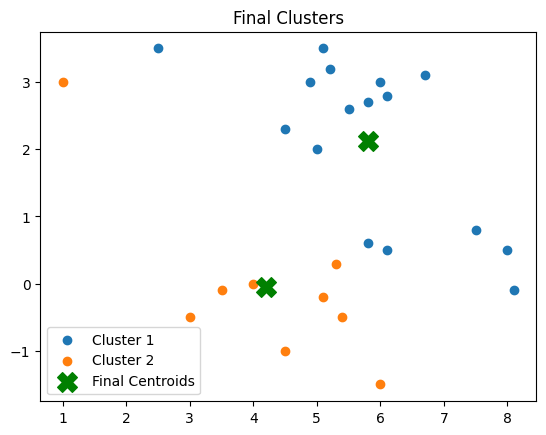


Final Centroids: [[ 5.8         2.125     ]
 [ 4.2        -0.05555556]]


In [5]:
for i in range(2):
    clusterPoints = X[labels == i]
    plt.scatter(clusterPoints[:, 0], clusterPoints[:, 1], label = "Cluster " + str(i + 1))
plt.scatter(finalCentroids[:, 0], finalCentroids[:, 1], c = 'green', marker = 'X', s = 200, label = "Final Centroids")
plt.title("Final Clusters")
plt.legend()
plt.show()

print()
print("Final Centroids: " + str(finalCentroids))

In [6]:
def randomInitializeCentroids(k):
    points = []
    for i in range(k):
        x = random.uniform(0, 8)
        y = random.uniform(-1, 4)
        points.append([x, y])
    return np.array(points)

def kMeans(X, k, maxIterations, threshold):
    centroids = randomInitializeCentroids(2)
    for iteration in range(maxIterations):
        labels = assignClusters(X, centroids)

        if iteration == 0:
            for i in range(k):
                clusterPoints = X[labels == i]
                plt.scatter(clusterPoints[:, 0], clusterPoints[:, 1], label = "Cluster " + str(i + 1))
            plt.scatter(centroids[:, 0], centroids[:, 1], c = 'green', marker = 'X', s = 200, label = "Initial Centroids")
            plt.title("Initial Clusters")
            plt.legend()
            plt.show()

        print()
        print("Starting iteration " + str(iteration + 1))
        newCentroids = updateCentroids(X, labels, k)
        print("Updated Centroids: " + str(newCentroids))

        if hasConverged(centroids, newCentroids, threshold):
            print()
            print("Convergence limit reached.")
            break

        centroids = newCentroids

    if iteration == maxIterations - 1:
        print()
        print("Maximum iterations reached.")

    print()
    for i in range(k):
        clusterPoints = X[labels == i]
        plt.scatter(clusterPoints[:, 0], clusterPoints[:, 1], label = "Cluster " + str(i + 1))
    plt.scatter(centroids[:, 0], centroids[:, 1], c = 'green', marker = 'X', s = 200, label = "Final Centroids")
    plt.title("Final Clusters")
    plt.legend()
    plt.show()

    return centroids, labels

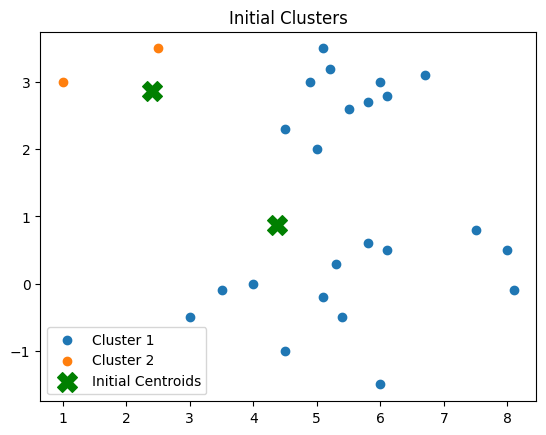


Starting iteration 1
Updated Centroids: [[5.52608696 1.17391304]
 [1.75       3.25      ]]

Starting iteration 2
Updated Centroids: [[5.52608696 1.17391304]
 [1.75       3.25      ]]

Convergence limit reached.



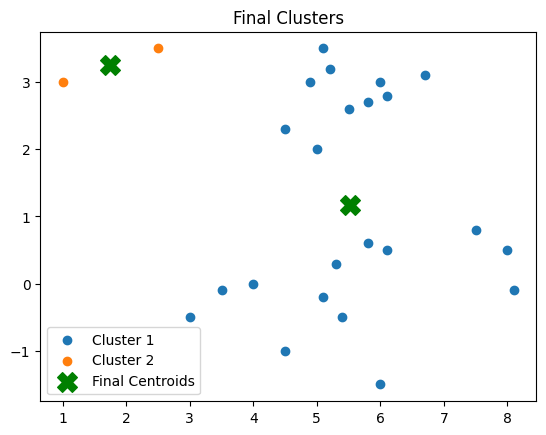

In [7]:
a, b = kMeans(X, 2, 100, 1e-4)

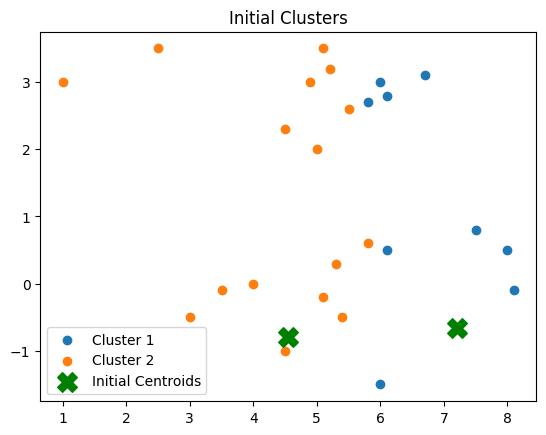


Starting iteration 1
Updated Centroids: [[6.7        1.31111111]
 [4.39375    1.35625   ]]

Starting iteration 2
Updated Centroids: [[6.61       1.24      ]
 [4.3        1.40666667]]

Starting iteration 3
Updated Centroids: [[6.5        1.08181818]
 [4.22142857 1.54285714]]

Starting iteration 4
Updated Centroids: [[6.3        0.92307692]
 [4.05833333 1.79166667]]

Starting iteration 5
Updated Centroids: [[6.17142857 0.78571429]
 [4.01818182 2.04545455]]

Starting iteration 6
Updated Centroids: [[6.21666667 0.44166667]
 [4.30769231 2.16923077]]

Starting iteration 7
Updated Centroids: [[ 6.18       -0.06      ]
 [ 4.58666667  2.27333333]]

Starting iteration 8
Updated Centroids: [[ 5.98181818 -0.05454545]
 [ 4.62857143  2.43571429]]

Starting iteration 9
Updated Centroids: [[ 5.56153846 -0.09230769]
 [ 4.85833333  2.89166667]]

Starting iteration 10
Updated Centroids: [[ 5.56153846 -0.09230769]
 [ 4.85833333  2.89166667]]

Convergence limit reached.



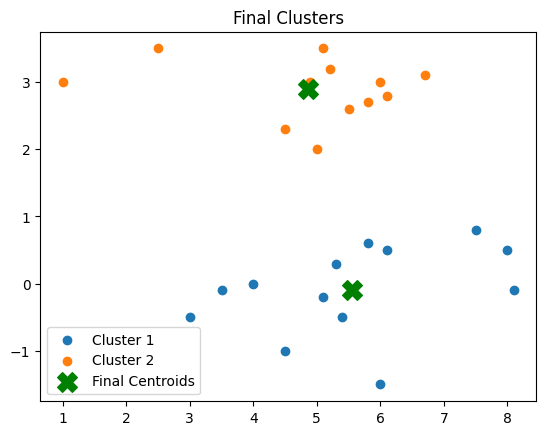

In [8]:
a, b = kMeans(X, 2, 100, 1e-4)

Checking for k =  1
Checking for k =  2
Checking for k =  3
Checking for k =  4
Checking for k =  5
Checking for k =  6
Checking for k =  7
Checking for k =  8
Checking for k =  9
Checking for k =  10


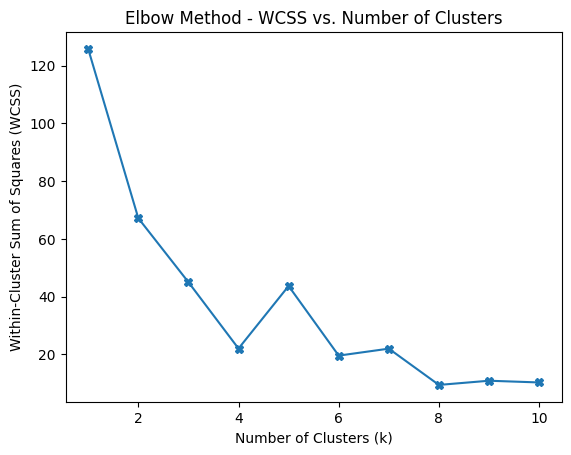

In [9]:
def kMeans(X, k, maxIterations, threshold):
    centroids = randomInitializeCentroids(k)

    for iteration in range(maxIterations):
        # print("Iteration " + str(iteration + 1) + " started.")
        labels = assignClusters(X, centroids)
        newCentroids = updateCentroids(X, labels, k)
        # print("Updated Centroids: " + str(newCentroids))
        if hasConverged(centroids, newCentroids, threshold):
            # print("Convergence limit reached.")
            break
        centroids = newCentroids
    if iteration == maxIterations - 1:
        # print("Maximum iterations reached.")
        pass

    return centroids, labels

def calculateWcss(X, centroids, labels):
    wcss = 0
    for i in range(len(centroids)):
        clusterPoints = X[labels == i]
        for point in clusterPoints:
            wcss += euclideanDistance(point, centroids[i]) ** 2
    return wcss

wcssValues = []
for k in range(1, 11):
    print("Checking for k = ", k)
    finalCentroids, labels = kMeans(X, k, 100, 1e-4)
    wcss = calculateWcss(X, finalCentroids, labels)
    wcssValues.append(wcss)

plt.plot(range(1, 11), wcssValues, marker = 'X')
plt.title('Elbow Method - WCSS vs. Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.show()

Iteration 1 started.
Updated Centroids: [[ 6.86    2.04  ]
 [ 2.875   0.6   ]
 [ 5.7875 -0.2375]
 [ 4.8125  2.85  ]]
Iteration 2 started.
Updated Centroids: [[ 7.075       1.8       ]
 [ 2.875       0.6       ]
 [ 5.7875     -0.2375    ]
 [ 4.94444444  2.86666667]]
Iteration 3 started.
Updated Centroids: [[ 7.575       1.075     ]
 [ 2.875       0.6       ]
 [ 5.45714286 -0.25714286]
 [ 5.06        2.86      ]]
Iteration 4 started.
Updated Centroids: [[ 7.86666667  0.4       ]
 [ 2.875       0.6       ]
 [ 5.45714286 -0.25714286]
 [ 5.20909091  2.88181818]]
Iteration 5 started.
Updated Centroids: [[ 7.86666667  0.4       ]
 [ 2.875       0.6       ]
 [ 5.45714286 -0.25714286]
 [ 5.20909091  2.88181818]]

Convergence limit reached.



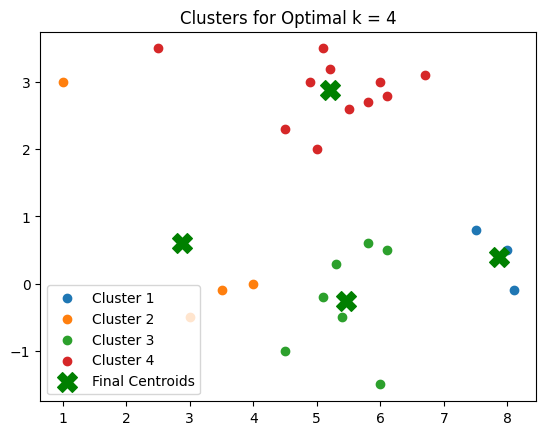

In [10]:
optimalK = 4
centroids = randomInitializeCentroids(optimalK)

def kMeans(X, k, maxIterations, threshold):
    centroids = randomInitializeCentroids(k)

    for iteration in range(maxIterations):
        print("Iteration " + str(iteration + 1) + " started.")
        labels = assignClusters(X, centroids)
        newCentroids = updateCentroids(X, labels, k)
        print("Updated Centroids: " + str(newCentroids))

        if hasConverged(centroids, newCentroids, threshold):
            print()
            print("Convergence limit reached.")
            break

        centroids = newCentroids
    if iteration == maxIterations - 1:
        print()
        print("Maximum iterations reached.")

    return centroids, labels

finalCentroids, labels = kMeans(X, optimalK, 100, 1e-4)

print()
for i in range(optimalK):
    clusterPoints = X[labels == i]
    plt.scatter(clusterPoints[:, 0], clusterPoints[:, 1], label = "Cluster " + str(i + 1))
plt.scatter(finalCentroids[:, 0], finalCentroids[:, 1], c = 'green', marker = 'X', s = 200, label = "Final Centroids")
plt.title("Clusters for Optimal k = 4")
plt.legend()
plt.show()